# 06 — Evaluation: Reproducible Paper-Quality Runs

**역할**: 4개 모델(`vanilla` / `periodic` / `trajectory` / **`trajectory_sync` = ours**)을 동일 MuJoCo Ant-v5 rollout protocol로 비교 + frequency controllability 분석 + paper figures 생성.

**산출물**: `results/table{1,2}_*.md`, `results/eval_results.npz`, `figures/eval_figure{1..5}_*.png`

**예상 소요**: **~75분** (Colab T4 GPU)
- Table 1 in-dist: 4 models × 20 seeds × 1000 steps ≈ 25분
- Table 2 sweep: 3 phase models × 5 freqs × 10 seeds × 1000 steps ≈ 50분


---

**평가 모델 (4개, `pcdp.configs.EXPERIMENT_CONFIGS`에 등록됨)**
- `vanilla` — Vanilla DP
- `periodic` — Periodic Phase
- `trajectory` — Phase Trajectory (sync 없는 ablation)
- `trajectory_sync` — **Phase Trajectory + Sync (ours)** (`phase_trajectory_sync_lambda0.12.pt`)

**평가 항목**
- Table 1: 4개 모델 in-distribution gait quality (`survival`, `reward/step`, `forward velocity`, `measured freq`)
- Table 2: 3개 phase 모델 frequency command tracking (`|freq_err|`, `PLV`, `reward/step`) — vanilla 제외
- Figure 1: 4개 모델 reward/step 비교
- Figure 2: 3개 phase 모델 reward/step vs commanded frequency
- Figure 3: commanded vs measured gait frequency (**trajectory + ours만**; periodic은 mode collapse(~1.2 Hz)로 plot 영역 밖이라 제외, annotation에 평균 measured freq 표시)
- Figure 4: zone-aggregated |freq err| + PLV
- Figure 5: 대표 rollout phase 시계열
- Raw arrays: `eval_results.npz`

---

이 노트북은 **실행 orchestration만 담당**합니다. 핵심 로직은 `pcdp/evaluation.py`(4개 모델 자동 로드 + `run_in_distribution_evaluation` + `run_frequency_sweep_evaluation` + table markdown export), `pcdp/sampling.py`(DDIM action chunk sampling + MuJoCo Ant rollout), `pcdp/phase.py`(target phase trajectory 생성 + Hilbert-derived measured phase + PLV / frequency error metrics), `pcdp/experiment_plots.py`(`plot_paper_figures` — ours 강조 styling + Figure 3에서 periodic mode collapse annotation)에 있습니다.

In [3]:
# Google Drive mount and project-root setup for Colab
from pathlib import Path
import os

PROJECT_DIR = Path('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy')

try:
    from google.colab import drive
except ImportError:
    print(f'Not running in Google Colab; keeping current working directory: {Path.cwd()}')
else:
    drive.mount('/content/drive')
    if not PROJECT_DIR.exists():
        raise FileNotFoundError(
            f'Expected project directory not found: {PROJECT_DIR}\n'
            'Update PROJECT_DIR to the Google Drive folder that contains this repository.'
        )
    os.chdir(PROJECT_DIR)
    print(f'Current working directory: {Path.cwd()}')


Mounted at /content/drive
Current working directory: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy


In [4]:
# Colab dependency setup
import importlib.util
import subprocess
import sys
from pathlib import Path

if importlib.util.find_spec("google.colab") is None:
    print("Not running in Google Colab; skipping dependency installation and using the current environment.")
else:
    project_root = Path.cwd()
    requirements_path = project_root / "requirements.txt"
    install_command = [sys.executable, "-m", "pip", "install"]

    if requirements_path.exists():
        # requirements.txt pins the runtime stack; -e . installs this repo from pyproject.toml.
        install_command.extend(["-r", str(requirements_path), "-e", str(project_root)])
    else:
        # Fallback to pyproject.toml dependencies if requirements.txt is unavailable.
        install_command.extend(["-e", str(project_root)])

    subprocess.check_call(install_command)

    import gymnasium as gym
    import mujoco
    import minari
    import torch

    gym.make("Ant-v5").close()

    print(f"gymnasium={gym.__version__}")
    print(f"mujoco={mujoco.__version__}")
    print(f"minari={minari.__version__}")
    print(f"torch={torch.__version__}")
    print("Ant-v5 environment smoke check passed.")


gymnasium=1.3.0
mujoco=3.9.0
minari=0.5.3
torch=2.11.0+cu128
Ant-v5 environment smoke check passed.


## 1. Artifact paths


In [5]:
from pcdp.paths import ARTIFACT_ROOT, DATA_DIR, CHECKPOINTS_DIR, RESULTS_DIR, FIGURES_DIR, ensure_artifact_dirs
ensure_artifact_dirs()
print(f'✓ artifact root: {ARTIFACT_ROOT}')


✓ artifact root: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts


## 2. Imports + Config


In [6]:
import gymnasium as gym
import torch

from pcdp.configs import set_global_seed
from pcdp.dataset import load_project_data
from pcdp.evaluation import (
    build_eval_results_payload,
    build_frequency_sweep_protocol,
    load_evaluation_state,
    print_frequency_sweep_summary,
    print_table1_summary,
    run_frequency_sweep_evaluation,
    write_frequency_tracking_table_markdown,
    write_table1_summary_markdown,
    run_in_distribution_evaluation,
    save_eval_results_npz,
)
from pcdp.experiment_plots import plot_paper_figures

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}, device={device}')

PyTorch 2.11.0+cu128, device=cuda


## 3. 데이터 및 체크포인트 로드

In [7]:
data = load_project_data(DATA_DIR)
set_global_seed(data['seed'], deterministic=True)


42

In [8]:
state = load_evaluation_state(data, device=device, checkpoints_dir=CHECKPOINTS_DIR)

# Phase labeling ablation 모델 추가 로드 (05에서 생성한 경우)
# EvaluationState는 frozen dataclass이므로 새로 생성해야 함
# 평가 루프가 쓰는 MODULE_KEYS도 함께 패치
from pcdp.frozen_phase_estimator import load_phase_sync_checkpoint
from pcdp.sampling import trajectory_phase_sample_cond_fn
from pcdp.configs import get_experiment_config
from pcdp.evaluation import ModelEvalSpec, EvaluationState
import pcdp.evaluation as eval_module

cfg_traj = get_experiment_config('phase_trajectory')
new_model_specs = dict(state.model_specs)
extra_keys = []

for method in ['multi_joint', 'pca']:
    ckpt_path = CHECKPOINTS_DIR / f'phase_trajectory_sync_{method}.pt'
    if ckpt_path.exists():
        model_m = cfg_traj.build_model(data, device=device)
        ema_m = cfg_traj.build_ema(model_m)
        load_phase_sync_checkpoint(ckpt_path, model_m, ema_m, device=device)
        key = f'sync_{method}'
        label = f'Sync {method.replace("_", "-").title()}'
        new_model_specs[key] = ModelEvalSpec(
            loaded_name=key,
            label=label,
            model=model_m,
            ema=ema_m,
            cond_fn=trajectory_phase_sample_cond_fn,
            uses_phase_trajectory=True,
        )
        extra_keys.append(key)
        print(f'Loaded: {label}')
    else:
        print(f'Skipped (not found): {ckpt_path.name}')

# frozen dataclass는 직접 수정 불가 → 새로 생성
state = EvaluationState(
    configs=state.configs,
    loaded_models=state.loaded_models,
    model_specs=new_model_specs,
    noise_scheduler_config=state.noise_scheduler_config,
    num_inference_steps=state.num_inference_steps,
)

# 평가 루프 / table export 함수가 참조하는 모듈 상수 확장
if extra_keys:
    eval_module.MODEL_KEYS = eval_module.MODEL_KEYS + tuple(extra_keys)
    eval_module.PHASE_MODEL_KEYS = eval_module.PHASE_MODEL_KEYS + tuple(extra_keys)
    for key in extra_keys:
        eval_module.SUMMARY_MODEL_LABELS[key] = new_model_specs[key].label
        eval_module.PHASE_CONDITION_LABELS[key] = 'full phase trajectory + labeling ablation'
    print(f'\nMODEL_KEYS: {eval_module.MODEL_KEYS}')
    print(f'PHASE_MODEL_KEYS: {eval_module.PHASE_MODEL_KEYS}')


✓ Loaded: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/checkpoints/vanilla_dp_ckpt.pt  [best EMA]
  Best val: (50, 0.12710950430482626)
✓ Loaded: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/checkpoints/phase_periodic_ckpt.pt  [best EMA]
  Best val: (50, 0.12699383776634932)
✓ Loaded: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/checkpoints/phase_trajectory_ckpt.pt  [best EMA]
  Best val: (50, 0.12193840835243464)
✓ Loaded: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/checkpoints/phase_trajectory_sync_lambda0.12.pt  [best EMA]
  Best val by total_loss: {'epoch': 11.0, 'diffusion_loss': 0.11675102636218071, 'phase_loss': 0.008605220878962427, 'total_loss': 0.1177836528676562}

✓ Evaluation checkpoints loaded
  Vanilla DP        : 68.23M trainable
  Periodic Phase    : 68.26M trainable
  Phase Trajectory  : 68.27M trainable
  Phase Trajectory + Sync (ours): 68.27M trainable
Loa

## 4. 평가 프로토콜 정의

In [9]:
DT = 0.05
MAX_STEPS = 1000
N_SEEDS_INDIST = 20
N_SEEDS_SWEEP = 10

freq_protocol = build_frequency_sweep_protocol(data, n_in_dist=3, ood_iqr_scale=1.5)

print(f"In-dist freqs: {freq_protocol.in_freqs.round(3).tolist()}")
print(f"OOD freqs:     {freq_protocol.ood_freqs.round(3).tolist()}")
print(f"Sweep freqs:   {freq_protocol.sweep_freqs.round(3).tolist()}")
print(f"Zones:         {freq_protocol.zone_labels.tolist()}")


In-dist freqs: [1.9249999523162842, 2.049999952316284, 2.174999952316284]
OOD freqs:     [1.5499999523162842, 2.549999952316284]
Sweep freqs:   [1.5499999523162842, 1.9249999523162842, 2.049999952316284, 2.174999952316284, 2.549999952316284]
Zones:         ['OOD-low (q25-1.5IQR)', 'in-dist (q25)', 'in-dist (q50)', 'in-dist (q75)', 'OOD-high (q75+1.5IQR)']


## 5. Table 1 — In-distribution performance

In [ ]:
env = gym.make('Ant-v5')
table1_results = run_in_distribution_evaluation(
    state,
    env=env,
    data=data,
    device=device,
    n_seeds=N_SEEDS_INDIST,
    max_steps=MAX_STEPS,
    dt=DT,
)


=== Table 1: In-dist @ f=2.023 Hz, n=20 seeds ===


--- Vanilla DP ---
  seed 0: survival=1000 steps, total_reward=  1003.1, reward/step= 1.003, x_vel= 0.480
  seed 1: survival=1000 steps, total_reward=   953.7, reward/step= 0.954, x_vel= 0.427
  seed 2: survival=1000 steps, total_reward=   668.8, reward/step= 0.669, x_vel= 0.089
  seed 3: survival=1000 steps, total_reward=   999.5, reward/step= 0.999, x_vel= 0.473
  seed 4: survival=1000 steps, total_reward=  1089.7, reward/step= 1.090, x_vel= 0.570
  seed 5: survival=1000 steps, total_reward=   995.4, reward/step= 0.995, x_vel= 0.451
  seed 6: survival=1000 steps, total_reward=  1084.8, reward/step= 1.085, x_vel= 0.582
  seed 7: survival=1000 steps, total_reward=   722.9, reward/step= 0.723, x_vel= 0.178
  seed 8: survival=1000 steps, total_reward=   814.0, reward/step= 0.814, x_vel= 0.223
  seed 9: survival=1000 steps, total_reward=   612.7, reward/step= 0.613, x_vel= 0.029
  seed 10: survival=1000 steps, total_reward=   730.1, rewa

In [ ]:
print_table1_summary(state, table1_results, freq_hz=float(data['freq_window_mean']))
write_table1_summary_markdown(
    state,
    table1_results,
    RESULTS_DIR / 'table1_indist_quality.md',
    freq_hz=float(data['freq_window_mean']),
    interval='ci95',
)



=== Table 1: In-distribution @ f=2.023 Hz, n=20 ===
                         Model  Survival   Reward/step  Forward vel. Measured freq
                    Vanilla DP  980 ± 86 0.827 ± 0.237 0.277 ± 0.252 1.376 ± 0.077
                Periodic Phase  1000 ± 0 0.783 ± 0.204 0.249 ± 0.211 1.299 ± 0.157
              Phase Trajectory 712 ± 340 1.492 ± 0.558 1.128 ± 0.458 1.892 ± 0.233
Phase Trajectory + Sync (ours) 707 ± 335 1.583 ± 0.332 1.196 ± 0.296 1.958 ± 0.128
              Sync Multi-Joint 756 ± 341 1.431 ± 0.412 1.061 ± 0.345 1.900 ± 0.208
                      Sync Pca 592 ± 387 1.553 ± 0.496 1.174 ± 0.456 1.937 ± 0.181
✓ /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/results/table1_indist_quality.md


PosixPath('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/results/table1_indist_quality.md')

## 6. Table 2 — Frequency command tracking

In [ ]:
freq_results = run_frequency_sweep_evaluation(
    state,
    freq_protocol,
    env=env,
    data=data,
    device=device,
    n_seeds=N_SEEDS_SWEEP,
    max_steps=MAX_STEPS,
    dt=DT,
)


In [ ]:
print_frequency_sweep_summary(data, freq_protocol, freq_results)
write_frequency_tracking_table_markdown(
    freq_protocol,
    freq_results,
    RESULTS_DIR / 'table2_frequency_tracking.md',
    interval='ci95',
)

=== Table 2: Frequency command tracking ===
freq_cmd                  zone                          model     freq_meas    |freq_err|           PLV   reward/step
   1.550  OOD-low (q25-1.5IQR)                 Periodic Phase 1.257 ± 0.076 0.293 ± 0.076 0.321 ± 0.063 0.757 ± 0.104
   1.550  OOD-low (q25-1.5IQR)               Phase Trajectory 1.521 ± 0.021 0.029 ± 0.021 0.898 ± 0.019 1.000 ± 0.088
   1.550  OOD-low (q25-1.5IQR) Phase Trajectory + Sync (ours) 1.510 ± 0.029 0.043 ± 0.025 0.894 ± 0.027 0.977 ± 0.080
   1.550  OOD-low (q25-1.5IQR)               Sync Multi-Joint 1.502 ± 0.036 0.048 ± 0.036 0.888 ± 0.037 0.995 ± 0.105
   1.550  OOD-low (q25-1.5IQR)                       Sync Pca 1.504 ± 0.033 0.046 ± 0.033 0.888 ± 0.030 1.044 ± 0.174
   1.925         in-dist (q25)                 Periodic Phase 1.321 ± 0.177 0.604 ± 0.177 0.313 ± 0.111 0.968 ± 0.262
   1.925         in-dist (q25)               Phase Trajectory 1.851 ± 0.134 0.074 ± 0.134 0.864 ± 0.135 1.709 ± 0.323
   1.925    

PosixPath('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/results/table2_frequency_tracking.md')

## 7. Figures — Contribution-focused visualizations

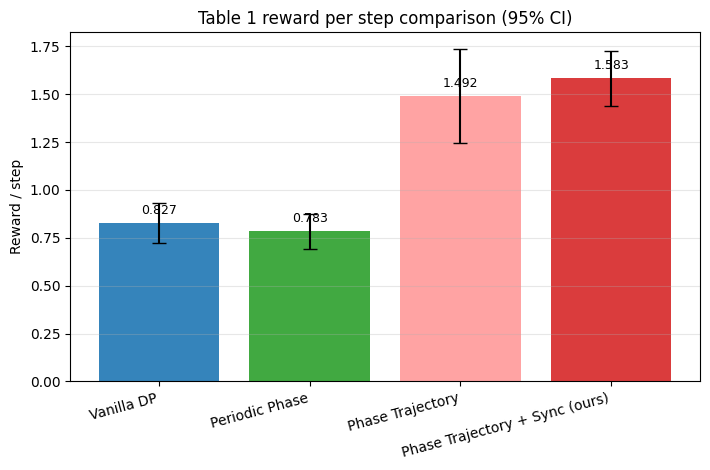

✓ /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure1_reward_per_step_comparison.png


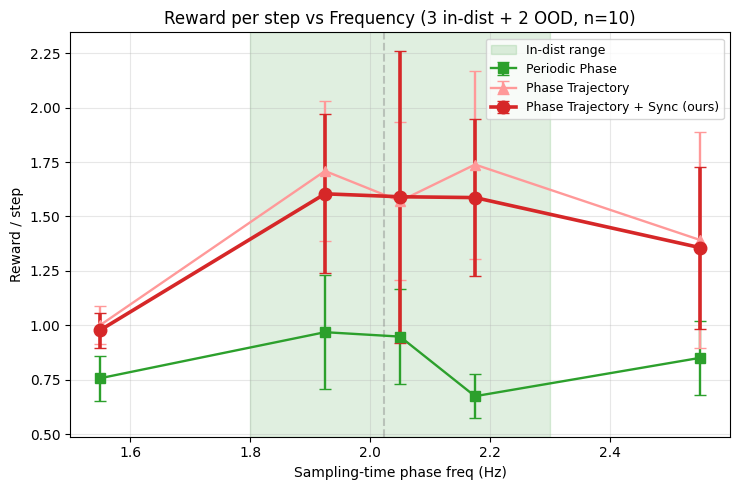

✓ /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure2_reward_per_step_vs_freq.png


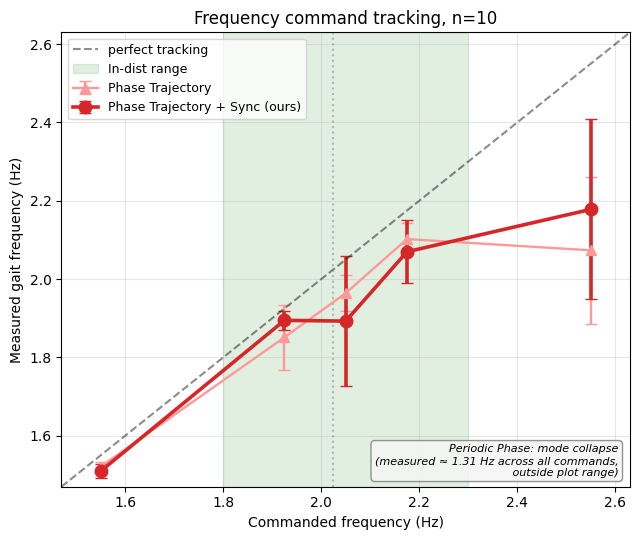

✓ /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure3_target_vs_measured_freq.png


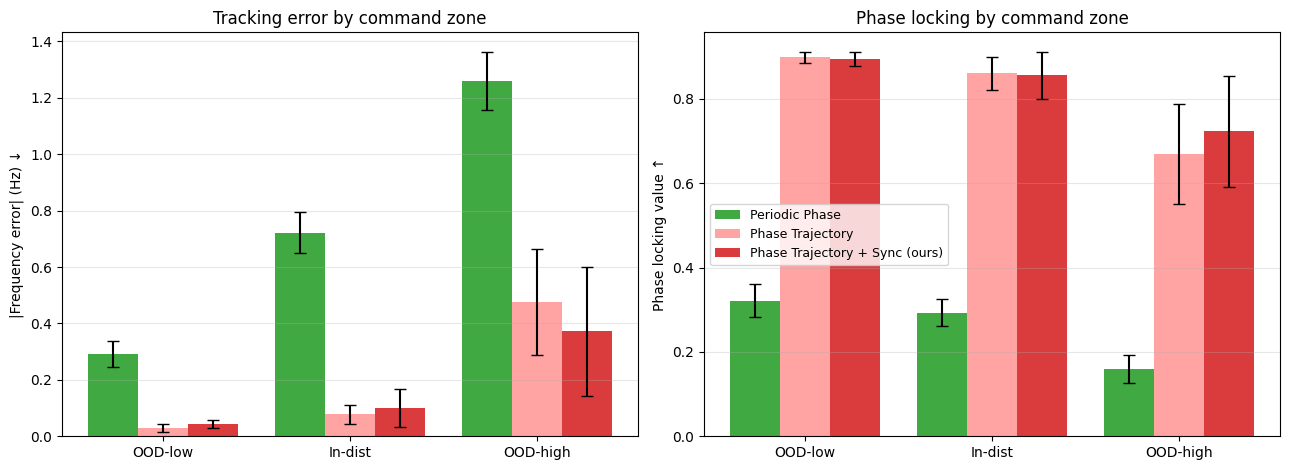

✓ /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure4_zone_tracking_metrics.png


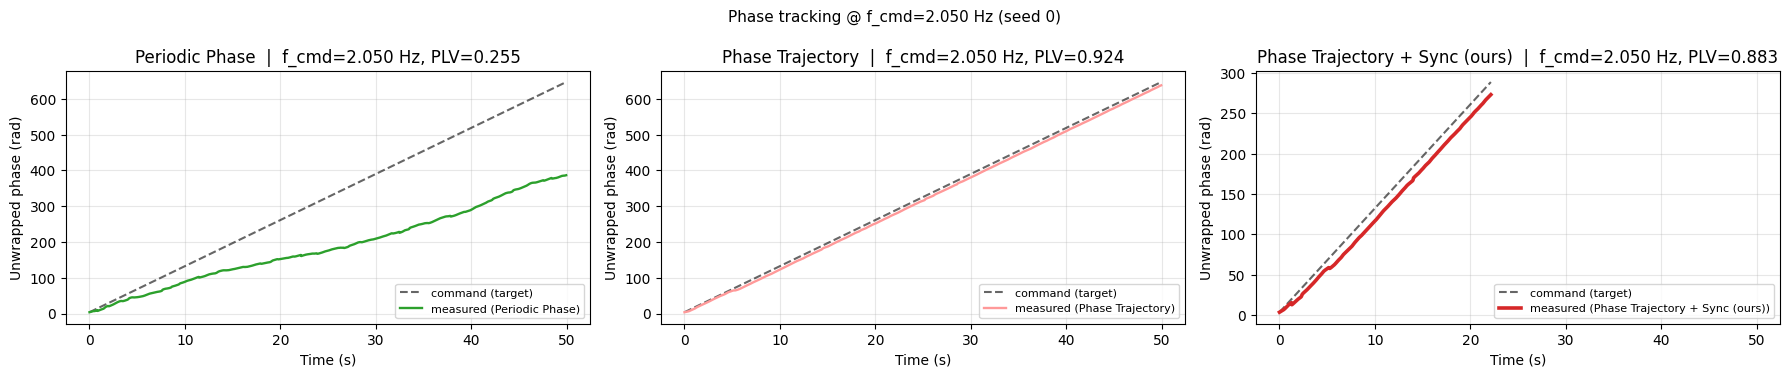

✓ /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure5_phase_tracking_timeseries.png


{'reward_per_step_comparison': PosixPath('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure1_reward_per_step_comparison.png'),
 'reward_per_step_vs_freq': PosixPath('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure2_reward_per_step_vs_freq.png'),
 'target_vs_measured_freq': PosixPath('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure3_target_vs_measured_freq.png'),
 'zone_tracking_metrics': PosixPath('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure4_zone_tracking_metrics.png'),
 'phase_tracking_timeseries': PosixPath('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/eval_figure5_phase_tracking_timeseries.png')}

In [ ]:
plot_paper_figures(
    table1_results,
    freq_results,
    freq_protocol,
    data,
    FIGURES_DIR,
    n_seeds_sweep=N_SEEDS_SWEEP,
    state=state,
    interval='ci95',
)

## 8. 결과 저장 — `eval_results.npz`

In [ ]:
eval_payload = build_eval_results_payload(
    data,
    table1_results,
    freq_protocol,
    freq_results,
    n_seeds_indist=N_SEEDS_INDIST,
    n_seeds_sweep=N_SEEDS_SWEEP,
)
save_eval_results_npz(eval_payload, RESULTS_DIR / 'eval_results.npz')